In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import skimage.transform

from copy import deepcopy
from glob import glob

In [2]:
raster_files = sorted(glob("../../src/full_detector/level2/2022/10/24/*.fits"))
raster_files

['../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221629_V04_150995397-000.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T221815_V04_150995397-001.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222001_V04_150995397-002.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222148_V04_150995397-003.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222334_V04_150995397-004.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222519_V04_150995397-005.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222705_V04_150995397-006.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T222851_V04_150995397-007.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spice-n-exp_20221024T223037_V04_150995397-008.fits',
 '../../src/full_detector/level2/2022/10/24/solo_L2_spi

In [3]:
test_raster_cube = read_spice_l2_fits(raster_files[0])

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-03 14:30:07 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]
2025-03-03 14:30:07 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.928116 from DATEREF.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'.
2025-03-03 14:30:07 - astropy - WARNING: UnitsWarning: 'W/m2/sr/nm' contains multiple slashes, which is discouraged by the FITS standard


In [4]:
test_raster_cube.keys()

dict_keys(['Full SW 4:1 Focal Lossy', 'Full LW 4:1 Focal Lossy'])

In [5]:
test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape

(1, 1024, 1024, 1)

In [6]:
sw_data = np.ones((test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[1],
                   test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[2],
                   len(raster_files)))*np.nan

lw_data = np.ones((test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[1],
                     test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[2],
                     len(raster_files)))*np.nan

sw_wcs_list = []
lw_wcs_list = []
sw_meta_list = []
lw_meta_list = []
sw_wvl_list = []
lw_wvl_list = []

for ii, file_ in enumerate(raster_files):
    datacube_ = read_spice_l2_fits(file_)
    sw_data[:,:,ii] = datacube_['Full SW 4:1 Focal Lossy'].data[0,:,:,0]
    lw_data[:,:,ii] = datacube_['Full LW 4:1 Focal Lossy'].data[0,:,:,0]
    sw_wcs_list.append(datacube_['Full SW 4:1 Focal Lossy'].wcs)
    lw_wcs_list.append(datacube_['Full LW 4:1 Focal Lossy'].wcs)
    sw_meta_list.append(datacube_['Full SW 4:1 Focal Lossy'].meta)
    lw_meta_list.append(datacube_['Full LW 4:1 Focal Lossy'].meta)
    sw_wvl_list.append(datacube_['Full SW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
    lw_wvl_list.append(datacube_['Full LW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
sw_data = np.flip(sw_data, axis=-1)
lw_data = np.flip(lw_data, axis=-1)

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-03 14:30:08 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74580365575 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.929352 from DATE-OBS.
Set MJD-BEG to 59876.929352 from DATE-BEG.
Set MJD-AVG to 59876.929697 from DATE-AVG.
Set MJD-END to 59876.930042 from DATE-END'. [astropy.wcs.wcs]
2025-03-03 14:30:08 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.929352 from DATEREF.
Set MJD-OBS to 59876.929352 from DATE-OBS.
Set MJD-BEG to 59876.929352 from DATE-BEG.
Set MJD-AVG to 59876.929697 from DATE-AVG.
Set MJD-END to 59876.930042 from DATE-END'.
keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-03 14:30:08 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74521961614 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.930

In [7]:
test_fit_NeVIII_wvl = sw_wvl_list[0][735:799]

In [8]:
NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)

/scratch/tmp.25002876.zhuyin/ipykernel_1920214/2019181606.py:1: RuntimeWarning: Mean of empty slice
  NeVIII_770_intmap = np.nanmean(sw_data[755:780,:,:], axis=0)
/scratch/tmp.25002876.zhuyin/ipykernel_1920214/2019181606.py:2: RuntimeWarning: Mean of empty slice
  NIV_765_intmap = np.nanmean(sw_data[705:725,:,:], axis=0)


In [9]:
cdelt1 = np.sqrt(np.sum((sw_wcs_list[0].wcs.crval[:2] - sw_wcs_list[1].wcs.crval[:2])**2))*3600
cdelt1

3.523144994791964

In [10]:
cdelt2 = sw_wcs_list[0].wcs.cdelt[1]*3600
cdelt2

1.098

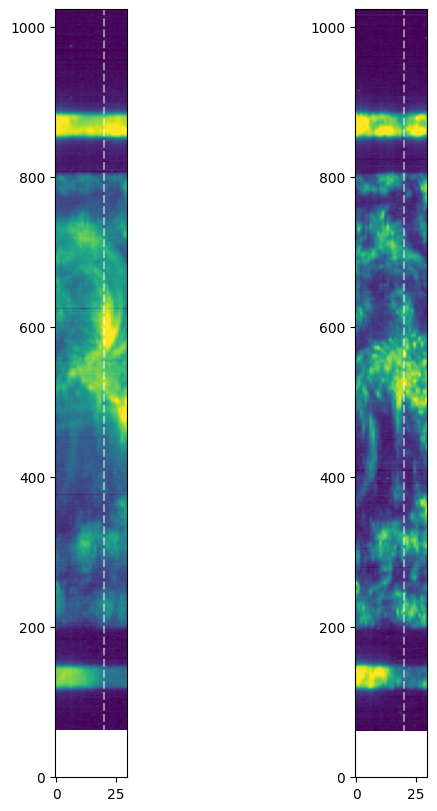

In [11]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,8),layout="constrained")
ax1.imshow(NeVIII_770_intmap, origin='lower',
           norm=ImageNormalize(vmin=np.nanpercentile(NeVIII_770_intmap, 1),
                               vmax=np.nanpercentile(NeVIII_770_intmap, 99),
                               stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

ax2.imshow(NIV_765_intmap, origin='lower',
              norm=ImageNormalize(vmin=np.nanpercentile(NIV_765_intmap, 1),
                                  vmax=np.nanpercentile(NIV_765_intmap, 99),
                                  stretch=AsinhStretch()), aspect=cdelt2/cdelt1)

for ax_ in (ax1,ax2):
    ax_.axvline(20, color='w', linestyle='--', alpha=0.5)

In [12]:
test_column_data_20 = sw_data[:,210:790,20]
test_column_data_20_NeVIII = test_column_data_20[735:799,:]
test_column_data_20_NIV = test_column_data_20[685:740,:]

In [13]:
with fits.open(raster_files[-21]) as hdul:
    test_column_dark_20_all, test_column_dark_20_sigma = spice_error(hdul[0])
    spice_hdr_20 = hdul[0].header.copy()
    spice_hdr_20_lw = hdul[1].header.copy()

Getting observation parameters from Full SW 4:1 Focal Lossy

Slit: 4.0 arcsec
Bin: (1, 1)
Exposure time: 59.6 s
Window width: 1024.0 pix
Average wavelength: 74.515895 nm
RADCAL: 580.263480489 m2 ct nm sr / W
            


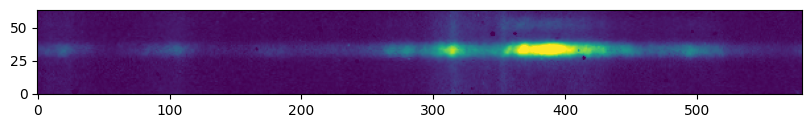

In [14]:
fig, ax = plt.subplots(figsize=(8,2), layout="constrained")
ax.imshow(test_column_data_20_NeVIII, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NeVIII, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NeVIII, 99.5),
                              stretch=AsinhStretch(0.9)))
ax.set_aspect(1)

(340.0, 380.0)

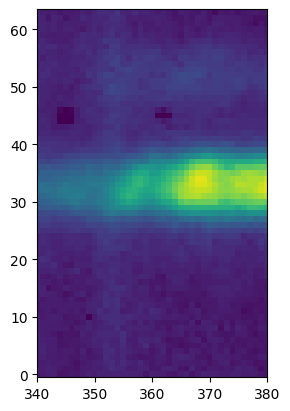

In [15]:
fig, ax = plt.subplots(figsize=(4,4), layout="constrained")
ax.imshow(test_column_data_20_NeVIII, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NeVIII, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NeVIII, 99.9),
                              stretch=AsinhStretch(0.9)))
ax.set_aspect(1)
ax.set_xlim(340, 380)

In [16]:
test_column_data_20_cut_upscale = skimage.transform.rescale(test_column_data_20_NeVIII[:,340:380],10)

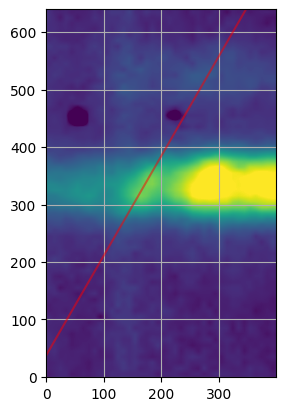

In [17]:
fig, ax = plt.subplots(figsize=(4,4), layout="constrained")
ax.imshow(test_column_data_20_cut_upscale, norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NeVIII, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NeVIII, 99.5),
                              stretch=AsinhStretch(0.9)),
                              origin="lower")
ax.set_aspect(1)
ax.grid("on")
ax.axline((180, 350), slope=np.tan(np.deg2rad(90-30)), color="red", alpha=0.5)

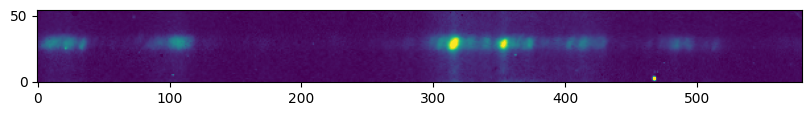

In [18]:
fig, ax = plt.subplots(figsize=(8,2), layout="constrained")
ax.imshow(test_column_data_20_NIV, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NIV, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NIV, 99.9),
                              stretch=AsinhStretch(0.9)))
ax.set_aspect(1)

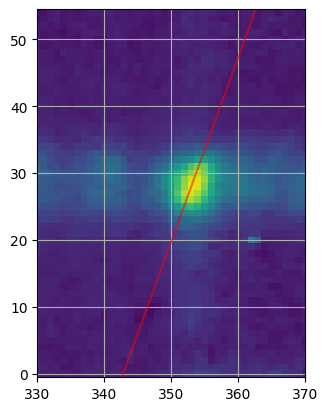

In [19]:
fig, ax = plt.subplots(figsize=(4,4), layout="constrained")
ax.imshow(test_column_data_20_NIV, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NIV, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NIV, 99.95),
                              stretch=AsinhStretch(0.9)))
ax.set_aspect(1)
ax.set_xlim(330, 370)
ax.grid("on")
ax.axline((353, 28), slope=np.tan(np.deg2rad(90-20)), color="red", alpha=0.5)

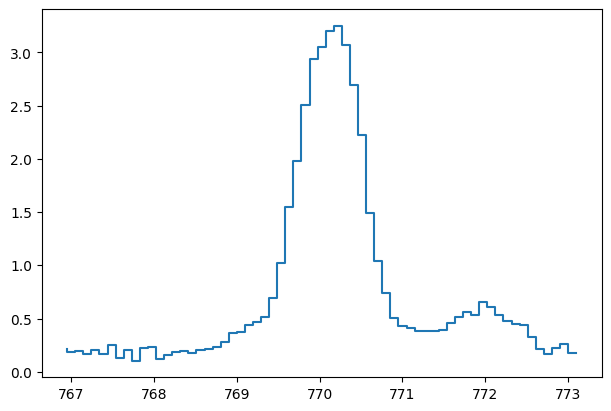

In [20]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(test_fit_NeVIII_wvl, test_column_data_20_NeVIII[:, 368])

In [21]:
def func_NeVIII_770(x, wvl_770, int_769, int_770, int_772, wid_770, wid_772, a, b):
    return gaussian(x, wvl_770-1.073, int_769, wid_772) + \
           gaussian(x, wvl_770, int_770, wid_770) + \
           gaussian(x, wvl_770+1.832, int_772, wid_772) + \
           a*x + b

In [22]:
test_column_dark_20_sigma["Total"].shape

(1, 1024, 1024, 1)

In [23]:
test_fit_NeVIII_model_20_368 = SpectrumFitSingle(data=test_column_data_20_NeVIII[:, 368],
                                        wvl=test_fit_NeVIII_wvl,
                                        err=test_column_dark_20_sigma["Total"][0,735:799,368,0].to_value(),
                                        custom_func=func_NeVIII_770,
                                        custom_init=[770.428, 0.2, 3, 0.2, 0.7, 0.7, 0, 0.2],)

test_fit_NeVIII_model_20_368.run_lse()

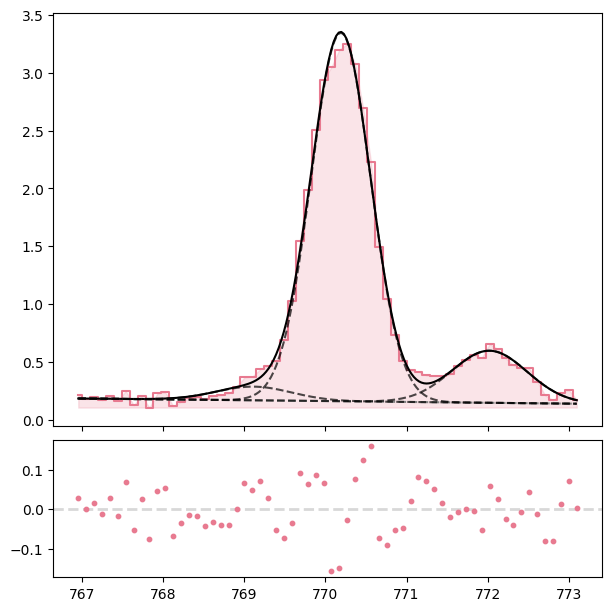

In [24]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(6,6), layout="constrained",
                            gridspec_kw={'height_ratios': [3,1]}, sharex=True)

test_fit_NeVIII_wvl_plot = np.linspace(test_fit_NeVIII_wvl[0], test_fit_NeVIII_wvl[-1], 200)

ax1.step(test_fit_NeVIII_wvl, test_fit_NeVIII_model_20_368.data, where='mid', color="#E87A90")
ax1.fill_between(test_fit_NeVIII_wvl, np.nanmin(test_fit_NeVIII_model_20_368.data), test_fit_NeVIII_model_20_368.data, color="#E87A90", alpha=0.2)
ax1.plot(test_fit_NeVIII_wvl_plot, func_NeVIII_770(test_fit_NeVIII_wvl_plot, *test_fit_NeVIII_model_20_368.custom_fit),
        color="black")

ax1.plot(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model_20_368.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model_20_368.custom_fit[7],
        color="grey", linestyle="dashed")

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model_20_368.custom_fit[0]-1.073,
                                           test_fit_NeVIII_model_20_368.custom_fit[1],
                                           test_fit_NeVIII_model_20_368.custom_fit[5]) + \
         test_fit_NeVIII_model_20_368.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model_20_368.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model_20_368.custom_fit[0],
                                           test_fit_NeVIII_model_20_368.custom_fit[2],
                                           test_fit_NeVIII_model_20_368.custom_fit[4]) + \
         test_fit_NeVIII_model_20_368.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model_20_368.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax1.plot(test_fit_NeVIII_wvl_plot, gaussian(test_fit_NeVIII_wvl_plot, test_fit_NeVIII_model_20_368.custom_fit[0]+1.832,
                                           test_fit_NeVIII_model_20_368.custom_fit[3],
                                           test_fit_NeVIII_model_20_368.custom_fit[5]) + \
         test_fit_NeVIII_model_20_368.custom_fit[6]*test_fit_NeVIII_wvl_plot + test_fit_NeVIII_model_20_368.custom_fit[7],
        color="black", linestyle="dashed", alpha=0.7)

ax2.scatter(test_fit_NeVIII_wvl, test_fit_NeVIII_model_20_368.data - func_NeVIII_770(test_fit_NeVIII_wvl, *test_fit_NeVIII_model_20_368.custom_fit),
            s=10, color="#E87A90")
ax2.axhline(0, color="grey", lw=2, ls="--", alpha=0.3, zorder=0)

In [25]:
test_NeVIII_data = sw_data[735:799,210:790,:]
test_NeVIII_data_corr = test_NeVIII_data - np.nanmean(test_NeVIII_data, axis=2)[:,:,np.newaxis]

# parameter set 1
yl_core_xpo = 1.0

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -20*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([5.5, 1.15])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([20.0, 4]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.21

spice_err_fac = 0.2 # Rough guess for the DN to count conversion and read noise level in SPICE
rebin_facs = [1,2,1]

test_NeVIII_data_corr_bin = bindown(test_NeVIII_data_corr,np.round(np.array(test_NeVIII_data_corr.shape)/rebin_facs).astype(np.int32))
test_NeVIII_data_corr_bin_trans = deepcopy(test_NeVIII_data_corr_bin).transpose([2,1,0]).astype(np.float64)

In [26]:
spice_hdr_20["CRPIX3"], spice_hdr_20["CRVAL3"]

(512.5, 74.515895)

In [27]:
spice_hdr_20_NeVIII = deepcopy(spice_hdr_20)
spice_hdr_20_NeVIII_new_naxis3 = 799 - 735
spice_hdr_20_NeVIII_new_crpix3 = (1 + 799 - 735)/2
spice_hdr_20_NeVIII_new_crval3 =  ((736 + 799)/2 - spice_hdr_20_NeVIII["CRPIX3"])*spice_hdr_20_NeVIII["CDELT3"] + spice_hdr_20_NeVIII["CRVAL3"]
spice_hdr_20_NeVIII["NAXIS3"] = spice_hdr_20_NeVIII_new_naxis3 
spice_hdr_20_NeVIII["CRPIX3"] = spice_hdr_20_NeVIII_new_crpix3
spice_hdr_20_NeVIII["CRVAL3"] = spice_hdr_20_NeVIII_new_crval3

In [28]:
spice_corr_dat, spice_corr_chi2s, metadict = correct_spice_raster(test_NeVIII_data_corr_bin_trans, spice_hdr_20_NeVIII, fwhm_core0_yl, fwhm_wing0_yl, 
                                                                  psf_yl_angle, wing_weight, super_fac=1, chi2_th = 0.5,yl_core_xpo=yl_core_xpo,
                                                                  psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
spice_corr_dat = spice_corr_dat.transpose([2,1,0])

Correcting Full SW 4:1 Focal Lossy; ref. wavelength=766.8564825000001
Computing PSF Core:
4.9948811897192735 % done after 2.9164748191833496 seconds
9.99515060078668 % done after 6.022120952606201 seconds
14.995420011854087 % done after 9.098362684249878 seconds
19.995689422921494 % done after 11.970439195632935 seconds
24.9959588339889 % done after 15.08070969581604 seconds
29.996228245056308 % done after 18.161564111709595 seconds
34.996497656123715 % done after 21.2305748462677 seconds
39.99676706719112 % done after 24.250009298324585 seconds
44.99703647825853 % done after 27.343148946762085 seconds
49.997305889325936 % done after 30.430943727493286 seconds
54.99757530039334 % done after 33.5678825378418 seconds
59.99784471146074 % done after 36.43380880355835 seconds
64.99811412252815 % done after 39.55659222602844 seconds
69.99838353359556 % done after 42.689035177230835 seconds
74.99865294466296 % done after 45.582358837127686 seconds
79.99892235573037 % done after 48.72588729858

2025-03-03 14:32:56 - numba.core.transforms - INFO: finding looplift candidates
/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py:83: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_masked_medfilt_inner" failed type inference due to: Use of unsupported NumPy function 'numpy.unravel_index' or unsupported use of the function.

File "../../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner(flatinds,data,footprint_inds,footprint_ind_offset,tparg,dat_pad_shape,data_fppad,mask_fppad,data_filt):
    <source elided>
    for ind in flatinds:
        ijkpad = np.unravel_index(ind,data.shape)+footprint_inds-footprint_ind_offset
        ^

During: typing of get attribute at /cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py (86)

File "../../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner

Correcting the PSF:
0.7601227760314941 s; Finished slit index 0 of 30 , chi^2= 0.07669516547894924
1.5060582160949707 s; Finished slit index 1 of 30 , chi^2= 0.04535364122892613
2.055629253387451 s; Finished slit index 2 of 30 , chi^2= 0.033312272015245274
2.5634310245513916 s; Finished slit index 3 of 30 , chi^2= 0.028239635886871433
3.0349385738372803 s; Finished slit index 4 of 30 , chi^2= 0.017425743812019598
3.7165770530700684 s; Finished slit index 5 of 30 , chi^2= 0.027290292355458552
4.3920814990997314 s; Finished slit index 6 of 30 , chi^2= 0.03879306918337849
5.1714768409729 s; Finished slit index 7 of 30 , chi^2= 0.07233755914528005
5.860273361206055 s; Finished slit index 8 of 30 , chi^2= 0.04322690721275867
6.701020002365112 s; Finished slit index 9 of 30 , chi^2= 0.05085456516276989
7.655803680419922 s; Finished slit index 10 of 30 , chi^2= 0.08544093561845406
8.625357866287231 s; Finished slit index 11 of 30 , chi^2= 0.09633679144475918
9.591369152069092 s; Finished slit

In [29]:
metadict

{'det_scale0': array([16.36363636, 36.        , 19.5034    ]),
 'det_dims0': array([ 30, 290,  64]),
 'det_origin0': array([     0.    ,      0.    , 153371.2965]),
 'src_dims0': array([ 30, 290,  64]),
 'src_origin0': array([     0.    ,      0.    , 153371.2965]),
 'src_scale0': array([16.36363636, 36.        , 19.5034    ]),
 'fwhm_core_yl': array([ 90., 230.]),
 'fwhm_wing_yl': array([327.27272727, 800.        ]),
 'psf_yl_angle': -0.3490658503988659,
 'fwhm_symm': array([36., 36.])}

In [30]:
spice_corr_dat.shape

(64, 290, 30)

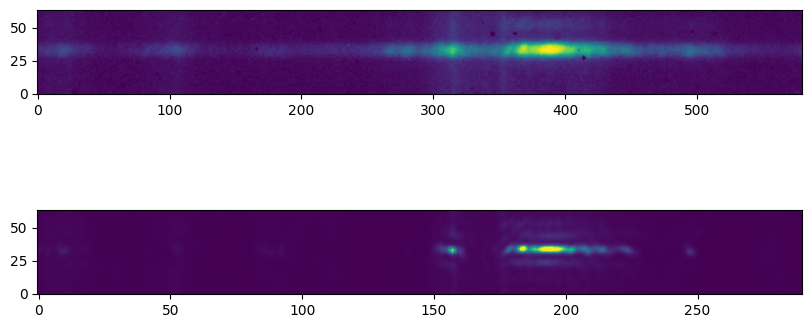

In [31]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(8,4), layout="constrained")

ax1.imshow(test_column_data_20_NeVIII, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NeVIII, 0.5),
                              vmax=np.nanpercentile(test_column_data_20_NeVIII, 99.95),
                              stretch=AsinhStretch(0.9)), aspect=1)

ax2.imshow(spice_corr_dat[:,:,20], origin="lower",
        norm=ImageNormalize(vmin=np.nanpercentile(spice_corr_dat[:,:,20], 0.5),
                              vmax=np.nanpercentile(spice_corr_dat[:,:,20], 99.9),
                              stretch=AsinhStretch(0.9)), aspect=0.5)

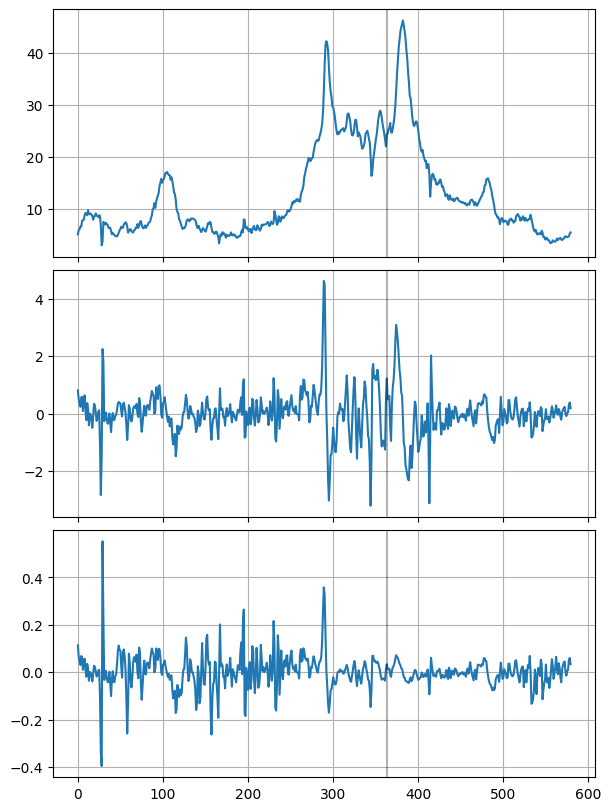

In [34]:
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(6,8),layout="constrained", sharex=True)
ax1.plot(np.nansum(test_NeVIII_data[:,:,24],axis=0))

ax2.plot(np.gradient(np.nansum(test_NeVIII_data[:,:,24],axis=0)))
ax3.plot(np.gradient(np.nansum(test_NeVIII_data[:,:,24],axis=0))/np.nansum(test_NeVIII_data[:,:,20],axis=0))

# ax1.set_xlim(350,400)

for ax_ in (ax1,ax2,ax3):
    ax_.grid("on")
    ax_.axvline(363, color="black", alpha=0.3)

In [36]:
find_peaks(np.gradient(np.nansum(test_NeVIII_data[:,:,24],axis=0)),
            height=4)

(array([289]), {'peak_heights': array([4.62097079])})

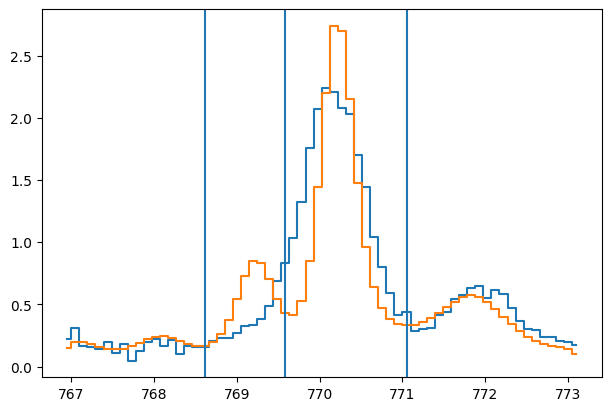

In [34]:
fig, ax = plt.subplots(figsize=(6,4), layout="constrained")
ax.step(test_fit_NeVIII_wvl, test_NeVIII_data_corr_bin[:,363//2,20], where="mid")
ax.step(test_fit_NeVIII_wvl, spice_corr_dat[:,363//2,20], where="mid")
# ax.set_yscale("log")
ax.axvline(test_fit_NeVIII_wvl[17])
ax.axvline(test_fit_NeVIII_wvl[27])
ax.axvline(test_fit_NeVIII_wvl[42])

In [35]:
print(test_fit_NeVIII_wvl[17], test_fit_NeVIII_wvl[27])

768.6117885 769.5869584999999


In [36]:
def gaussian_with_bg(x, wvl, int_total, width, bg):
    return gaussian(x, wvl, int_total, width) + bg

In [37]:
NeVIII_row_20_orig_fit_wvl = np.zeros(25)
NeVIII_row_20_orig_fit_int = np.zeros(25)
NeVIII_row_20_orig_fit_wid = np.zeros(25)
NeVIII_row_20_corr_fit_wvl = np.zeros(25)
NeVIII_row_20_corr_fit_int = np.zeros(25)
NeVIII_row_20_corr_fit_wid = np.zeros(25)

for ii in range(175,200):
    popt, pcov = curve_fit(gaussian_with_bg,
                        test_fit_NeVIII_wvl[np.r_[3:17,27:42]],
                        test_NeVIII_data_corr_bin[np.r_[3:17,27:42], ii, 20],
                        p0=[test_fit_NeVIII_wvl[np.nanargmax(test_NeVIII_data_corr_bin[:,ii,20])],
                        np.nanmax(test_NeVIII_data_corr_bin[:,ii,20]),
                        0.7, np.nanmean(test_NeVIII_data_corr_bin[3:15,ii,20])])
    
    NeVIII_row_20_orig_fit_int[ii-175] = popt[1]
    NeVIII_row_20_orig_fit_wvl[ii-175] = popt[0]
    NeVIII_row_20_orig_fit_wid[ii-175] = popt[2]

    popt, pcov = curve_fit(gaussian_with_bg,
                        test_fit_NeVIII_wvl[np.r_[3:17,27:42]],
                        spice_corr_dat[np.r_[3:17,27:42], ii, 20],
                        p0=[test_fit_NeVIII_wvl[np.nanargmax(spice_corr_dat[:,ii,20])],
                        np.nanmax(spice_corr_dat[:,ii,20]),
                        0.7, np.nanmean(spice_corr_dat[3:15,ii,20])])

    NeVIII_row_20_corr_fit_int[ii-175] = popt[1]
    NeVIII_row_20_corr_fit_wvl[ii-175] = popt[0]
    NeVIII_row_20_corr_fit_wid[ii-175] = popt[2]

(0.3, 1.0)

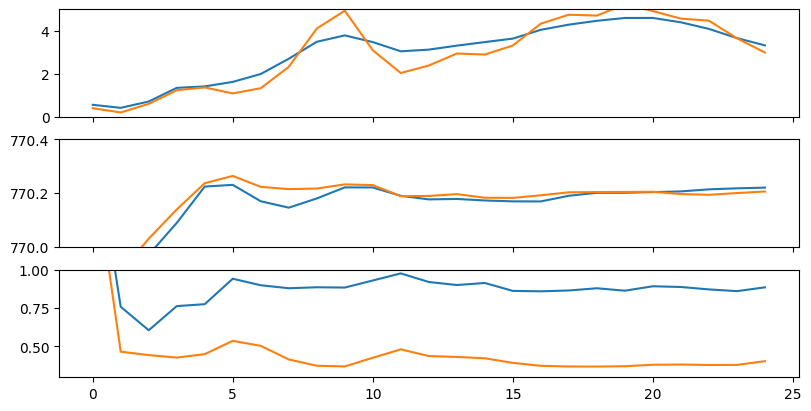

In [38]:
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(8,4),layout="constrained", sharex=True)

ax1.plot(NeVIII_row_20_orig_fit_int)
ax1.plot(NeVIII_row_20_corr_fit_int)
ax2.plot(NeVIII_row_20_orig_fit_wvl)
ax2.plot(NeVIII_row_20_corr_fit_wvl)
ax3.plot(NeVIII_row_20_orig_fit_wid)
ax3.plot(NeVIII_row_20_corr_fit_wid)

ax1.set_ylim(0,5)
ax2.set_ylim(770.0, 770.4)
ax3.set_ylim(0.3,1)

Text(0.2, 0.3, 'sigma_wvl_corr: 0.0192')

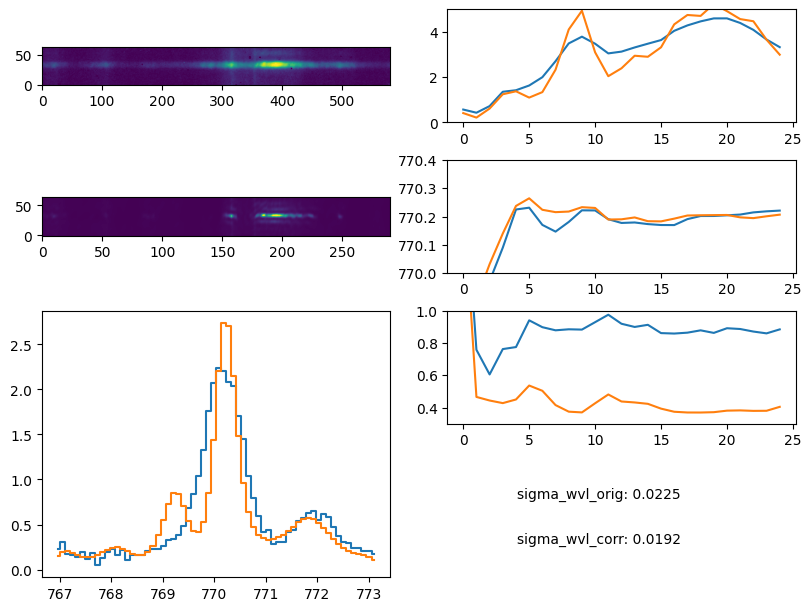

In [39]:
axd = plt.figure(figsize=(8,6),layout="constrained").subplot_mosaic(
    """
    AD
    BE
    CF
    CG
    """
)

axd["A"].imshow(test_column_data_20_NeVIII, origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_column_data_20_NeVIII, 3),
                              vmax=np.nanpercentile(test_column_data_20_NeVIII, 99.95),
                              stretch=AsinhStretch(0.5)), aspect=1)
axd["B"].imshow(spice_corr_dat[:,:,20], origin="lower",
        norm=ImageNormalize(vmin=np.nanpercentile(spice_corr_dat[:,:,20], 3),
                              vmax=np.nanpercentile(spice_corr_dat[:,:,20], 99.95),
                              stretch=AsinhStretch(0.5)), aspect=0.5)

axd["C"].step(test_fit_NeVIII_wvl, test_NeVIII_data_corr_bin[:,363//2,20], where="mid")
axd["C"].step(test_fit_NeVIII_wvl, spice_corr_dat[:,363//2,20], where="mid")

ax1.plot(NeVIII_row_20_orig_fit_int)
ax1.plot(NeVIII_row_20_corr_fit_int)
ax2.plot(NeVIII_row_20_orig_fit_wvl)
ax2.plot(NeVIII_row_20_corr_fit_wvl)
ax3.plot(NeVIII_row_20_orig_fit_wid)
ax3.plot(NeVIII_row_20_corr_fit_wid)

ax1.set_ylim(0,5)
ax2.set_ylim(770.0, 770.4)
ax3.set_ylim(0.3,1)

axd["D"].plot(NeVIII_row_20_orig_fit_int)
axd["D"].plot(NeVIII_row_20_corr_fit_int)
axd["E"].plot(NeVIII_row_20_orig_fit_wvl)
axd["E"].plot(NeVIII_row_20_corr_fit_wvl)
axd["F"].plot(NeVIII_row_20_orig_fit_wid)
axd["F"].plot(NeVIII_row_20_corr_fit_wid)

axd["D"].set_ylim(0,5)
axd["E"].set_ylim(770.0, 770.4)
axd["F"].set_ylim(0.3,1)

axd["G"].axis("off")
axd["G"].text(0.2, 0.7, f"sigma_wvl_orig: {np.nanstd(NeVIII_row_20_orig_fit_wvl[5:]):.4f}")
axd["G"].text(0.2, 0.3, f"sigma_wvl_corr: {np.nanstd(NeVIII_row_20_corr_fit_wvl[5:]):.4f}")

In [167]:
test_data_OVI = lw_data[725:780,210:790,:]
test_data_OVI_corr = test_data_OVI - np.nanmin(test_data_OVI, axis=2)[:,:,np.newaxis]
test_fit_OVI_wvl = lw_wvl_list[20][725:780]

yl_core_xpo = 1.0

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -13*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([5.5, 1.15])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([20.0, 4]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.21

rebin_facs = [1,1,1]

test_OVI_data_corr_bin = bindown(test_data_OVI_corr,np.round(np.array(test_data_OVI_corr.shape)/rebin_facs).astype(np.int32))
test_data_OVI_corr_bin_trans = deepcopy(test_OVI_data_corr_bin).transpose([2,1,0]).astype(np.float64)

In [168]:
spice_hdr_20_OVI = deepcopy(spice_hdr_20_lw)
spice_hdr_20_OVI_new_naxis3 = 780 - 725
spice_hdr_20_OVI_new_crpix3 = (1 + 780 - 725)/2
spice_hdr_20_OVI_new_crval3 =  ((725 + 780)/2 - spice_hdr_20_OVI["CRPIX3"])*spice_hdr_20_OVI["CDELT3"] + spice_hdr_20_OVI["CRVAL3"]
spice_hdr_20_OVI["NAXIS3"] = spice_hdr_20_OVI_new_naxis3 
spice_hdr_20_OVI["CRPIX3"] = spice_hdr_20_OVI_new_crpix3
spice_hdr_20_OVI["CRVAL3"] = spice_hdr_20_OVI_new_crval3

In [169]:
spice_corr_dat_OVI, spice_corr_chi2s_OVI, metadict_OVI = correct_spice_raster(test_data_OVI_corr_bin_trans[20:22,:,:], spice_hdr_20_OVI, fwhm_core0_yl, fwhm_wing0_yl, 
                                                                  psf_yl_angle, wing_weight, super_fac=1, chi2_th = 0.5,
                                                                  psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
spice_corr_dat_OVI = spice_corr_dat_OVI.transpose([2,1,0])

Correcting Full LW 4:1 Focal Lossy; ref. wavelength=1028.75636
Computing PSF Core:
4.9970218502147405 % done after 2.9461240768432617 seconds
9.99717859494028 % done after 6.075411319732666 seconds
14.99733533966582 % done after 9.210617780685425 seconds
19.99749208439136 % done after 12.138062715530396 seconds
24.9976488291169 % done after 15.256542444229126 seconds
29.99780557384244 % done after 18.395198583602905 seconds
34.99796231856798 % done after 21.33095693588257 seconds
39.99811906329352 % done after 24.454107522964478 seconds
44.99827580801906 % done after 27.57901906967163 seconds
49.9984325527446 % done after 30.525457859039307 seconds
54.99858929747014 % done after 33.656946659088135 seconds
59.99874604219568 % done after 36.79890990257263 seconds
64.99890278692122 % done after 39.91740965843201 seconds
69.99905953164676 % done after 42.90184187889099 seconds
74.9992162763723 % done after 46.03867173194885 seconds
79.99937302109784 % done after 49.16333556175232 seconds
8

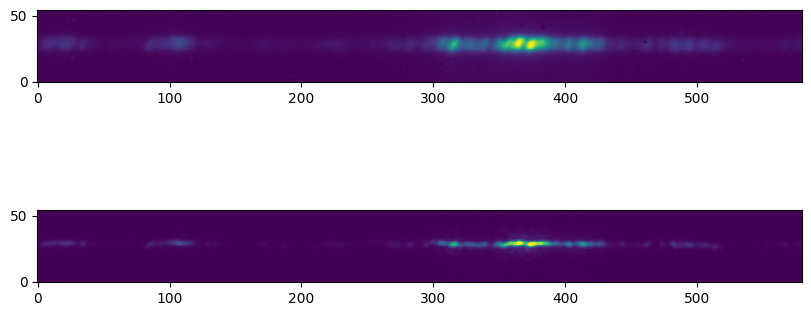

In [173]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(8,4), layout="constrained")

ax1.imshow(test_data_OVI[:,:,20], origin="lower",
          norm=ImageNormalize(vmin=np.nanpercentile(test_data_OVI[:,:,20], 0.5),
                              vmax=np.nanpercentile(test_data_OVI[:,:,20], 99.95),
                              stretch=AsinhStretch(0.9)), aspect=1)

ax2.imshow(spice_corr_dat_OVI[:,:,0], origin="lower",
        norm=ImageNormalize(vmin=np.nanpercentile(spice_corr_dat_OVI[:,:,0], 0.5),
                              vmax=np.nanpercentile(spice_corr_dat_OVI[:,:,0], 99.95),
                              stretch=AsinhStretch(0.9)), aspect=1)

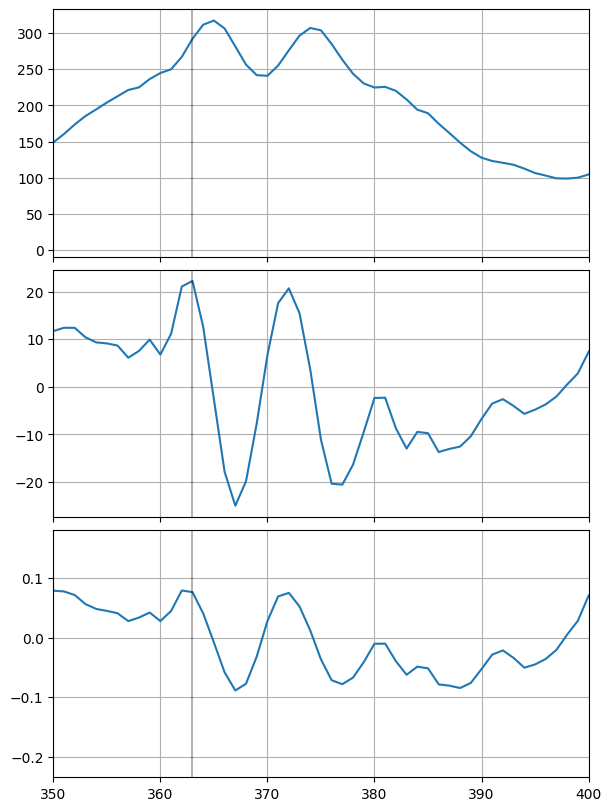

In [179]:
fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(6,8),layout="constrained", sharex=True)
ax1.plot(np.nansum(test_data_OVI[:,:,20],axis=0))

ax2.plot(np.gradient(np.nansum(test_data_OVI[:,:,20],axis=0)))
ax3.plot(np.gradient(np.nansum(test_data_OVI[:,:,20],axis=0))/np.nansum(test_data_OVI[:,:,20],axis=0))

ax1.set_xlim(350,400)

for ax_ in (ax1,ax2,ax3):
    ax_.grid("on")
    ax_.axvline(363, color="black", alpha=0.3)

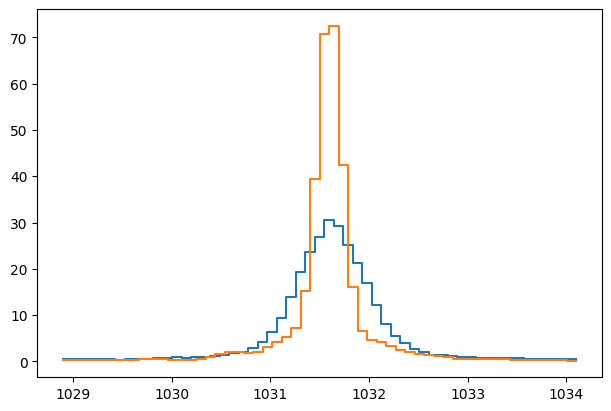

In [178]:
fig, ax = plt.subplots(figsize=(6,4), layout="constrained")
ax.step(test_fit_OVI_wvl, test_data_OVI[:,363,20], where="mid")
ax.step(test_fit_OVI_wvl, spice_corr_dat_OVI[:,363,0])
# ax.set_yscale("log")